# Equivariant SSL Tutorial Notebook

Code is based of https://github.com/SonyCSLParis/pesto-full

## imports

In [1]:
from typing import Any, Optional, Dict
from typing import Sequence, Tuple, Any
from typing import Any, Dict, Mapping, Sequence, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import mirdata

import hashlib
import itertools
import json
import logging
from pathlib import Path
from functools import partial
from dataclasses import dataclass
from collections import defaultdict

from omegaconf import OmegaConf

from nnAudio.features.cqt import CQT

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from lightning import LightningDataModule
from lightning import LightningModule
import lightning.pytorch as pl

from math import cos, pi

/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Download Data

If you want you can download the data yourself and not the preprocessed version. You can then calcualte the HCQTs yourself.

In [2]:

# Initialize the loader
mdb_stem_synth = mirdata.initialize('mdb_stem_synth', data_home='data/mdb_stem_synth')

# Download the dataset
mdb_stem_synth.download()

## utils

In [3]:
def remove_omegaconf_dependencies(obj: Any) -> Any:
    if OmegaConf.is_config(obj):
        return OmegaConf.to_container(obj, resolve=True)
    if isinstance(obj, dict):
        return {k: remove_omegaconf_dependencies(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [remove_omegaconf_dependencies(e) for e in obj]
    return obj


In [4]:
def reduce_activations(activations: torch.Tensor, reduction: str = "alwa") -> torch.Tensor:
    r"""

    Args:
        activations: tensor of probability activations, shape (batch_size, num_bins)
        reduction (str): reduction method to compute pitch out of activations,
            choose between "argmax", "mean", "alwa".

    Returns:
        torch.Tensor: pitches as fractions of MIDI semitones, shape (batch_size)
    """
    device = activations.device
    num_bins = activations.size(1)
    bps, r = divmod(num_bins, 128)
    assert r == 0, "Activations should have output size 128*bins_per_semitone"

    if reduction == "argmax":
        pred = activations.argmax(dim=1)
        return pred.float() / bps

    all_pitches = torch.arange(num_bins, dtype=torch.float, device=device).div_(bps)
    if reduction == "mean":
        return torch.mm(activations, all_pitches)

    if reduction == "alwa":  # argmax-local weighted averaging, see https://github.com/marl/crepe
        center_bin = activations.argmax(dim=1, keepdim=True)
        window = torch.arange(1, 2 * bps, device=device) - bps
        indices = (window + center_bin).clip_(min=0, max=num_bins - 1)
        cropped_activations = activations.gather(1, indices)
        cropped_pitches = all_pitches.unsqueeze(0).expand_as(activations).gather(1, indices)
        return (cropped_activations * cropped_pitches).sum(dim=1) / cropped_activations.sum(dim=1)

    raise ValueError

In [5]:
def mid_to_hz(pitch: int):
    return 440 * 2 ** ((pitch - 69) / 12)


def generate_synth_data(pitch: int, num_harmonics: int = 5, duration=2, sr=16000):
    f0 = mid_to_hz(pitch)
    t = torch.arange(0, duration, 1/sr)
    harmonics = torch.stack([
        torch.cos(2 * torch.pi * k * f0 * t + torch.rand(()))
        for k in range(1, num_harmonics+1)
    ], dim=1)
    # volume = torch.randn(()) * torch.arange(num_harmonics).neg().div(0.5).exp()
    volume = torch.rand(num_harmonics)
    volume[0] = 1
    volume *= torch.randn(())
    audio = torch.sum(volume * harmonics, dim=1)
    return audio


## data preprocessing

In [6]:
@dataclass
class DataConfig:
	
    harmonics: tuple = (1,)
    hop_duration: float = 10.
    fmin: float = 27.5
    # fmax: float = 4186.01
    bins_per_semitone: int = 3
    n_bins: int = 88
    center_bins: bool = True
    batch_size: int = 256

cfg = DataConfig()
cfg

DataConfig(harmonics=(1,), hop_duration=10.0, fmin=27.5, bins_per_semitone=3, n_bins=88, center_bins=True, batch_size=256)

### Harmonic CQT

In [7]:
class HarmonicCQT(nn.Module):
    def __init__(
            self,
            harmonics,
            sr: int = 22050,
            hop_length: int = 512,
            fmin: float = 32.7,
            fmax: float | None = None,
            bins_per_semitone: int = 1,
            n_bins: int = 84,
            center_bins: bool = True
    ):
        super(HarmonicCQT, self).__init__()

        if center_bins:
            fmin = fmin / 2 ** ((bins_per_semitone - 1) / (24 * bins_per_semitone))

        self.cqt_kernels = nn.ModuleList([
            CQT(sr=sr, hop_length=hop_length, fmin=h*fmin, fmax=fmax, n_bins=n_bins,
                bins_per_octave=12*bins_per_semitone, output_format="Complex", verbose=False)
            for h in harmonics
        ])

    def forward(self, audio_waveforms: torch.Tensor):
        r"""

        Returns:
            Harmonic CQT, shape (num_channels, num_harmonics, num_freqs, num_timesteps, 2)
        """
        return torch.stack([cqt(audio_waveforms) for cqt in self.cqt_kernels], dim=1)


## Transforms

In [8]:
class ToLogMagnitude(nn.Module):
    def __init__(self):
        super(ToLogMagnitude, self).__init__()
        self.eps = torch.finfo(torch.float32).eps

    def forward(self, x):
        if x.size(-1) == 2:
            x = torch.view_as_complex(x)
        if x.ndim == 2:
            x.unsqueeze_(1)
        x = x.abs()
        x.clamp_(min=self.eps).log10_().mul_(20)
        return x


class BatchRandomNoise(nn.Module):
    def __init__(
            self,
            min_snr: float = 0.0001,
            max_snr: float = 0.01,
            p: Optional[float] = None,
    ):
        super(BatchRandomNoise, self).__init__()
        self.min_snr = min_snr
        self.max_snr = max_snr

        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        device = x.device

        snr = torch.empty(batch_size, device=device)
        snr.uniform_(self.min_snr, self.max_snr)
        mask = torch.rand_like(snr).le(self.p)
        snr[mask] = 0

        noise_std = snr * x.view(batch_size, -1).std(dim=-1)
        noise_std = noise_std.unsqueeze(-1).expand_as(x.view(batch_size, -1)).view_as(x)

        # compute ratios corresponding to gain in dB
        noise = noise_std * torch.randn_like(x)

        return x + noise


class BatchRandomGain(nn.Module):
    def __init__(
            self,
            min_gain: float = 0.5,
            max_gain: float = 1.5,
            p: Optional[float] = None,
    ):
        super(BatchRandomGain, self).__init__()
        self.min_gain = min_gain
        self.max_gain = max_gain

        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        device = x.device

        vol = torch.empty(batch_size, device=device)
        vol.uniform_(self.min_gain, self.max_gain)
        mask = torch.rand_like(vol).le(self.p)
        vol[mask] = 1
        vol = vol.unsqueeze(-1).expand_as(x.view(batch_size, -1)).view_as(x)
        return vol * x


In [9]:
def randint_sampling_fn(min_value, max_value):
    def sample_randint(*size, **kwargs):
        return torch.randint(min_value, max_value+1, size, **kwargs)

    return sample_randint


def gaussint_sampling_fn(min_value, max_value):
    mean = (min_value + max_value) / 2
    std = (max_value - mean) / 2
    def sample_gaussint(*size, **kwargs):
        return torch.randn(size, **kwargs).add_(mean).mul_(std).long().clip(min=min_value, max=max_value)
    return sample_gaussint


class PitchShiftCQT(nn.Module):
    def __init__(self,
                 min_steps: int,
                 max_steps: int,
                 gaussian_sampling: bool = False):
        super(PitchShiftCQT, self).__init__()
        self.min_steps = min_steps
        self.max_steps = max_steps

        self.sample_random_steps = gaussint_sampling_fn(min_steps, max_steps) if gaussian_sampling \
            else randint_sampling_fn(min_steps, max_steps)

        # lower bin
        self.lower_bin = self.max_steps

    def forward(self, spectrograms: torch.Tensor):
        batch_size, _, input_height = spectrograms.size()
        output_height = input_height - self.max_steps + self.min_steps
        assert output_height > 0, \
            f"With input height {input_height:d} and output height {output_height:d}, impossible " \
            f"to have a range of {self.max_steps - self.min_steps:d} bins."

        n_steps = self.sample_random_steps(batch_size, device=spectrograms.device)
        x = spectrograms[..., self.lower_bin: self.lower_bin + output_height]
        xt = self.extract_bins(spectrograms, self.lower_bin - n_steps, output_height)

        return x, xt, n_steps

    def extract_bins(self, inputs: torch.Tensor, first_bin: torch.LongTensor, output_height: int):
        r"""Efficiently extract subsegments of CQT of size `output_height`,
        i.e. so that outputs[i, j] = inputs[i, ..., first_bin[j] : first_bin[j] + self.output_height]

        Args:
            inputs (torch.Tensor): tensor of CQTs, shape (batch_size, num_channels, input_height)
            first_bin (torch.LongTensor): indices of the first bin of each segment, shape (batch_size)
            output_height (int): output height of the cropped CQT

        Returns:
            segments of CQTs, shape (batch_size, num_channels, output_height)
        """
        indices = first_bin.unsqueeze(-1) + torch.arange(output_height, device=inputs.device)
        dims = inputs.size(0), 1, output_height

        output_size = list(inputs.size())[:-1] + [output_height]
        indices = indices.view(*dims).expand(output_size)
        return inputs.gather(-1, indices)


## Torch Dataset

In [10]:
log = logging.getLogger(__name__)


def hz_to_mid(freqs):
    return np.where(freqs > 0, 12 * np.log2(freqs / 440) + 69, 0)


class NpyDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels=None, filter_unvoiced: bool = False) -> None:
        assert labels is None or len(inputs) == len(labels), "Lengths of inputs and labels do not match"
        if filter_unvoiced and labels is None:
            log.warning("Cannnot filter out unvoiced frames without annotations.")
            filter_unvoiced = False
        if filter_unvoiced:
            self.inputs = inputs[labels > 0]
            self.labels = labels[labels > 0]
        else:
            self.inputs = inputs
            self.labels = labels

    def __getitem__(self, item) -> Tuple[torch.Tensor, torch.Tensor]:
        label = self.labels[item] if self.labels is not None else 0
        return torch.view_as_complex(torch.from_numpy(self.inputs[item])), label

    def __len__(self):
        return len(self.inputs)


class AudioDataModule(LightningDataModule):
    def __init__(self,
                 audio_files: str,
                 annot_files: str | None = None,
                 val_audio_files: str | None = None,
                 val_annot_files: str | None = None,
                 harmonics: Sequence[float] = (1,),
                 hop_duration: float = 10.,
                 fmin: float = 27.5,
                 fmax: float | None = None,
                 bins_per_semitone: int = 1,
                 n_bins: int = 84,
                 center_bins: bool = False,
                 batch_size: int = 256,
                 num_workers: int = 0,
                 pin_memory: bool = False,
                 transforms: Sequence[torch.nn.Module] | None = None,
                 fold: int | None = None,
                 n_folds: int = 5,
                 cache_dir: str = "./cache",
                 filter_unvoiced: bool = False,
                 mmap_mode: str | None = None):
        r"""

        Args:
            audio_files: path to csv file containing the list of audio files to process

        """
        super(AudioDataModule, self).__init__()

        # sanity checks
        assert val_audio_files is None or val_annot_files is not None, "Validation set (if it exists) must be annotated"
        assert val_audio_files is None or fold is None, "Specify `val_audio_files` OR cross-validation `fold`, not both"
        assert annot_files is not None or fold is None, "Cannot perform cross-validation without any annotations."

        self.audio_files = Path(audio_files)
        self.annot_files = Path(annot_files) if annot_files is not None else None

        if val_audio_files is not None:
            self.val_audio_files = Path(val_audio_files)
            self.val_annot_files = Path(val_annot_files)
        else:
            self.val_audio_files = None
            self.val_annot_files = None

        self.fold = fold
        self.n_folds = n_folds

        # HCQT
        self.hcqt_sr = None
        self.hcqt_kernels = None
        self.hop_duration = hop_duration

        self.hcqt_kwargs = dict(
            harmonics=list(harmonics),
            fmin=fmin,
            fmax=fmax,
            bins_per_semitone=bins_per_semitone,
            n_bins=n_bins,
            center_bins=center_bins
        )

        # dataloader keyword-arguments
        self.dl_kwargs = dict(
            batch_size=batch_size,
            num_workers=num_workers,
            pin_memory=pin_memory
        )

        # transforms
        self.transforms = nn.Sequential(*transforms) if transforms is not None else nn.Identity()

        # misc
        self.cache_dir = Path(cache_dir)
        self.filter_unvoiced = filter_unvoiced
        self.mmap_mode = mmap_mode

        # placeholders for datasets and samplers
        self.train_dataset = None
        self.train_sampler = None
        self.val_dataset = None
        self.val_sampler = None

    def prepare_data(self) -> None:
        self.train_dataset = self.load_data(self.audio_files, self.annot_files)
        if self.val_audio_files is not None:
            self.val_dataset = self.load_data(self.val_audio_files, self.val_annot_files)

    def setup(self, stage: str) -> None:
        # If the dataset is labeled, we split it randomly and keep 20% for validation only
        # Otherwise we train on the whole dataset
        if self.val_dataset is not None:
            return

        if not self.annot_files:
            # create dummy validation set
            self.val_dataset = NpyDataset(np.zeros_like(self.train_dataset.inputs[:1]))
            return

        self.val_dataset = self.load_data(self.audio_files, self.annot_files)

        if self.fold is not None:
            # see https://github.com/christianversloot/machine-learning-articles/blob/main/how-to-use-k-fold-cross-validation-with-pytorch.md
            from sklearn.model_selection import KFold

            # We fix random_state=0 for the train/val split to be consistent across runs, even if the global seed changes
            kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=0)
            iterator = kfold.split(self.train_dataset)
            train_idx, val_idx = None, None  # just to make the linter shut up
            for _ in range(self.fold + 1):
                train_idx, val_idx = next(iterator)

            self.train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
            self.val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

        else:
            self.train_sampler = torch.utils.data.RandomSampler(self.train_dataset)
            self.val_sampler = torch.utils.data.SequentialSampler(self.val_dataset)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(self.train_dataset, sampler=self.train_sampler, **self.dl_kwargs)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(self.val_dataset, sampler=self.val_sampler, **self.dl_kwargs)

    def on_after_batch_transfer(self, batch: Any, dataloader_idx: int) -> Any:
        x, y = batch
        return self.transforms(x), y

    def load_data(self, audio_files: Path, annot_files: Path | None = None) -> torch.utils.data.Dataset:
        cache_cqt = self.build_cqt_filename(audio_files)
        if cache_cqt.exists():
            inputs = np.load(cache_cqt, mmap_mode=self.mmap_mode)
            cache_annot = cache_cqt.with_suffix(".csv")
            annotations = np.loadtxt(cache_annot, dtype=np.float32) if cache_annot.exists() else None
        else:
            self.cache_dir.mkdir(parents=True, exist_ok=True)
            inputs, annotations = self.precompute_hcqt(audio_files, annot_files)
            np.save(cache_cqt, inputs, allow_pickle=False)
            if annotations is not None:
                np.savetxt(cache_cqt.with_suffix(".csv"), annotations)
        return NpyDataset(inputs, labels=annotations, filter_unvoiced=self.filter_unvoiced)

    def build_cqt_filename(self, audio_files) -> Path:
        # build a hash
        dict_str = json.dumps({
            "audio_files": str(audio_files),
            "hop_duration": self.hop_duration,
            **self.hcqt_kwargs
        }, sort_keys=True)
        hash_id = hashlib.sha256(dict_str.encode()).hexdigest()[:8]

        # build filename
        fname = "hcqt_" + hash_id + ".npy"
        return self.cache_dir / fname

    def precompute_hcqt(self, audio_path: Path, annot_path: Path | None = None) -> Tuple[np.ndarray,np.ndarray]:
        data_dir = audio_path.parent

        cqt_list = []
        with audio_path.open('r') as f:
            audio_files = f.readlines()

        if annot_path is not None:
            with annot_path.open('r') as f:
                annot_files = f.readlines()
            annot_list = []
        else:
            annot_files = []
            annot_list = None

        log.info("Precomputing HCQT...")
        pbar = tqdm(itertools.zip_longest(audio_files, annot_files, fillvalue=None),
                    total=len(audio_files),
                    leave=False)
        for fname, annot in pbar:
            fname = fname.strip()
            pbar.set_description(fname)
            x, sr = torchaudio.load(data_dir / fname)
            out = self.hcqt(x.mean(dim=0), sr)  # convert to mono and compute HCQT

            if annot is not None:
                annot = annot.strip()
                timesteps, freqs = np.loadtxt(data_dir / annot, delimiter=',', dtype=np.float32).T
                hop_duration = 1000 * (timesteps[1] - timesteps[0])

                # Badly-aligned annotations is a fucking nightmare
                # so we double-check for each file that hop sizes and lengths do match.
                # Since hop sizes are floats we put a tolerance of 1e-6 in the equality
                assert abs(hop_duration - self.hop_duration) < 1e-6, \
                    (f"Inconsistency between {fname} and {annot}:\n"
                     f"the resolution of the annotations ({len(freqs):d}) "
                     f"does not match the number of CQT frames ({len(out):d}). "
                     f"The hop duration between CQT frames should be identical "
                     f"but got {hop_duration:.1f} ms vs {self.hop_duration:.1f} ms. "
                     f"Please either adjust the hop duration of the CQT or resample the annotations.")
                assert len(out) == len(freqs), \
                    (f"Inconsistency between {fname} and {annot}:"
                     f"the resolution of the annotations ({len(freqs):d}) "
                     f"does not match the number of CQT frames ({len(out):d}) "
                     f"despite hop durations match. "
                     f"Please check that your annotations are correct.")
                annot_list.append(hz_to_mid(freqs))

            cqt_list.append(out.cpu().numpy())

        return np.concatenate(cqt_list), np.concatenate(annot_list) if annot_list is not None else None

    def hcqt(self, audio: torch.Tensor, sr: int):
        # compute CQT kernels if it does not exist yet
        if sr != self.hcqt_sr:
            self.hcqt_sr = sr
            hop_length = int(self.hop_duration * sr / 1000 + 0.5)
            self.hcqt_kernels = HarmonicCQT(sr=sr, hop_length=hop_length, **self.hcqt_kwargs)

        return self.hcqt_kernels(audio).squeeze(0).permute(2, 0, 1, 3)  # (time, harmonics, freq_bins, 2)


## Losses

In [11]:
class NullLoss(nn.Module):
    def forward(self, *args, **kwargs) -> torch.Tensor:
        return args[0].mean().mul(0)

In [12]:
class HuberLoss(nn.Module):
    def __init__(self, tau: float):
        super(HuberLoss, self).__init__()
        self.register_buffer("tau", torch.tensor(tau), persistent=False)

    def forward(self, x):
        x = x.abs()
        return torch.where(x.le(self.tau),
                           x ** 2 / 2,
                           self.tau ** 2 / 2 + self.tau * (x - self.tau))


class PowerSeries(nn.Module):
    def __init__(self, value: float, power_min, power_max, tau: float = 1.):
        super(PowerSeries, self).__init__()
        self.value = value

        # compute weights vector
        powers = torch.arange(power_min, power_max)
        self.register_buffer("weights", self.value ** powers, persistent=False)

        self.dim = len(self.weights)
        self.loss_fn = HuberLoss(tau)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor, target: torch.Tensor,
                nlog_c1: torch.Tensor | None = None, nlog_c2: torch.Tensor | None = None) -> Dict[str, torch.Tensor]:
        r"""x2[i] is the pitch-shifted version of x1[i] by target[i] semitones, i.e.
            if x1[i] is a C# and x2[i] is a C then target[i] = -1

        """
        z1 = self.project(x1)
        z2 = self.project(x2)
        if nlog_c1 is not None:
            z1 = z1 * torch.exp(-nlog_c1)
        if nlog_c2 is not None:
            z2 = z2 * torch.exp(-nlog_c2)

        # compute frequency ratios out of semitones
        freq_ratios = self.value ** target.float()

        # compute equivariant loss
        loss_12 = self.loss_fn(z2 / z1 - freq_ratios).mean()
        loss_21 = self.loss_fn(z1 / z2 - 1/freq_ratios).mean()

        return (loss_12 + loss_21) / 2

    def project(self, x: torch.Tensor):
        r"""Projects a batch of vectors into a batch of scalars
        Args:
            x (torch.Tensor): batch of input vectors, shape (batch_size, output_dim)

        Returns:
            torch.Tensor: batch of output scalars, shape (batch_size)
        """
        return x.mv(self.weights)


In [13]:
class CrossEntropyLoss(nn.Module):
    def __init__(self,
                 symmetric: bool = False,
                 detach_targets: bool = False,
                 backend: nn.Module = nn.CrossEntropyLoss()) -> None:
        super(CrossEntropyLoss, self).__init__()
        self.symmetric = symmetric
        self.detach_targets = detach_targets
        self.backend = backend

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        if self.symmetric:
            return (self.compute_loss(input, target) + self.compute_loss(target, input)) / 2
        return self.compute_loss(input, target)

    def compute_loss(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.backend(input, target.detach() if self.detach_targets else target)


class ShiftCrossEntropy(nn.Module):
    def __init__(self,
                 pad_length: int = 5,
                 criterion: nn.Module = CrossEntropyLoss()):
        super(ShiftCrossEntropy, self).__init__()
        self.criterion = criterion
        self.pad_length = pad_length

    def forward(self, x1: torch.Tensor, x2: torch.Tensor, target: torch.Tensor) -> Dict[str, torch.Tensor]:
        r"""x2[i] is the pitch-shifted version of x1[i] by target[i] semitones, i.e.
            if x1[i] is a C# and x2[i] is a C then target[i] = -1

        """
        # pad x1 and x2
        x1 = F.pad(x1, (self.pad_length, self.pad_length))
        x2 = F.pad(x2, (2*self.pad_length, 2*self.pad_length))

        # shift x2
        idx = target.unsqueeze(1) + torch.arange(x1.size(-1), device=target.device) + self.pad_length
        shift_x2 = torch.gather(x2, dim=1, index=idx)

        # compute loss
        return self.criterion(x1, shift_x2)


## Callbacks

In [14]:

class LossWeighting(pl.Callback):
    def __init__(self, weights: Mapping[str, float] | None = None) -> None:
        self.weights = weights if weights is not None else defaultdict(lambda: 1.)

    def on_train_batch_end(self,
                           trainer: pl.Trainer,
                           pl_module: pl.LightningModule,
                           outputs: Any,
                           batch: Any,
                           batch_idx: int) -> None:
        pl_module.log_dict({f"hparams/{k}_weight": v for k, v in self.weights.items()}, prog_bar=False, logger=True)

    def combine_losses(self, **losses):
        self.update_weights(losses)
        return sum([self.weights[key] * losses[key] for key in self.weights.keys()])

    def update_weights(self, losses):
        pass

    def __str__(self):
        params = '\n'.join(f"\t{k}: {v}" for k, v in vars(self).items())
        return self.__class__.__name__ + "(\n" + params + "\n)"


class WarmupLossWeighting(LossWeighting):
    def __init__(
            self,
            weights: Mapping[str, float],
            warmup_term: str,
            warmup_epochs: int = 10,
            initial_weight: float = 0.,
            warmup_fn: str = "linear"
    ):
        super(WarmupLossWeighting, self).__init__(weights)
        self.key = warmup_term
        self.warmup_epochs = warmup_epochs
        self.initial_weight = initial_weight
        self.target_weight = self.weights[self.key]
        self.warmup_fn = warmup_fn

    def on_train_epoch_start(self, trainer: pl.Trainer, pl_module: pl.LightningModule) -> None:
        epoch = trainer.current_epoch
        if epoch >= self.warmup_epochs:
            self.weights[self.key] = self.target_weight
            return

        # compute new value for the weight
        if self.warmup_fn == "linear":
            weight = (self.target_weight - self.initial_weight) * epoch / self.warmup_epochs + self.initial_weight
        elif self.warmup_fn == "cosine":
            weight = 0.5 * (1 - cos(pi * epoch / self.warmup_epochs)) * (self.target_weight - self.initial_weight) + self.initial_weight
        else:
            raise NotImplementedError(f"This warmup schedule is not supported: `{self.warmup_fn}`.")

        self.weights[self.key] = weight


class GradientsLossWeighting(LossWeighting):
    def __init__(self,
                 weights: Mapping[str, float] | None = None,
                 last_layer: Optional[torch.Tensor] = None,
                 ema_rate: float = 0.):
        super(GradientsLossWeighting, self).__init__(weights)
        self.last_layer = last_layer
        self.ema_rate = ema_rate
        self.grads = {k: 1-v for k, v in weights.items()}
        self.weights_tensor = None

    def on_fit_start(self, trainer: pl.Trainer, pl_module: pl.LightningModule) -> None:
        self.weights_tensor = torch.zeros(len(self.weights.keys()), device=pl_module.device)

    def update_weights(self, losses):
        # compute gradient w.r.t last layer for each loss term
        for i, (k, loss) in enumerate(losses.items()):
            if not loss.requires_grad:
                return

            grads = torch.autograd.grad(loss, self.get_last_layer(k), retain_graph=True)[0].norm().detach()
            old_grads = self.grads[k]
            if old_grads is not None:
                grads = self.ema_rate * old_grads + (1 - self.ema_rate) * grads
            self.grads[k] = grads
            self.weights_tensor[i] = grads

        # compute the weight of this loss based on these gradients
        self.weights_tensor = 1 - self.weights_tensor / self.weights_tensor.sum().clip(min=1e-7)

        # associate each weight with the right loss
        for i, k in enumerate(losses.keys()):
            self.weights[k] = self.weights_tensor[i]

    def get_last_layer(self, key: str) -> torch.Tensor:
        if torch.is_tensor(self.last_layer):
            return self.last_layer
        return self.last_layer[key]



## model

In [15]:
class ToeplitzLinear(nn.Conv1d):
    def __init__(self, in_features, out_features):
        super(ToeplitzLinear, self).__init__(
            in_channels=1,
            out_channels=1,
            kernel_size=in_features+out_features-1,
            padding=out_features-1,
            bias=False
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return super(ToeplitzLinear, self).forward(input.unsqueeze(-2)).squeeze(-2)


class Resnet1d(nn.Module):
    """
    Basic CNN similar to the one in Johannes Zeitler's report,
    but for longer HCQT input (always stride 1 in time)
    Still with 75 (-1) context frames, i.e. 37 frames padded to each side
    The number of input channels, channels in the hidden layers, and output
    dimensions (e.g. for pitch output) can be parameterized.
    Layer normalization is only performed over frequency and channel dimensions,
    not over time (in order to work with variable length input).
    Outputs one channel with sigmoid activation.

    Args (Defaults: BasicCNN by Johannes Zeitler but with 6 input channels):
        n_chan_input:     Number of input channels (harmonics in HCQT)
        n_chan_layers:    Number of channels in the hidden layers (list)
        n_prefilt_layers: Number of repetitions of the prefiltering layer
        residual:         If True, use residual connections for prefiltering (default: False)
        n_bins_in:        Number of input bins (12 * number of octaves)
        n_bins_out:       Number of output bins (12 for pitch class, 72 for pitch, num_octaves * 12)
        a_lrelu:          alpha parameter (slope) of LeakyReLU activation function
        p_dropout:        Dropout probability
    """

    def __init__(self,
                 n_chan_input=1,
                 n_chan_layers=(20, 20, 10, 1),
                 n_prefilt_layers=1,
                 prefilt_kernel_size=15,
                 residual=False,
                 n_bins_in=216,
                 output_dim=128,
                 activation_fn: str = "leaky",
                 a_lrelu=0.3,
                 p_dropout=0.2):
        super(Resnet1d, self).__init__()

        self.hparams = dict(n_chan_input=n_chan_input,
                            n_chan_layers=n_chan_layers,
                            n_prefilt_layers=n_prefilt_layers,
                            prefilt_kernel_size=prefilt_kernel_size,
                            residual=residual,
                            n_bins_in=n_bins_in,
                            output_dim=output_dim,
                            activation_fn=activation_fn,
                            a_lrelu=a_lrelu,
                            p_dropout=p_dropout)

        if activation_fn == "relu":
            activation_layer = nn.ReLU
        elif activation_fn == "silu":
            activation_layer = nn.SiLU
        elif activation_fn == "leaky":
            activation_layer = partial(nn.LeakyReLU, negative_slope=a_lrelu)
        else:
            raise ValueError

        n_in = n_chan_input
        n_ch = n_chan_layers
        if len(n_ch) < 5:
            n_ch.append(1)

        # Layer normalization over frequency and channels (harmonics of HCQT)
        self.layernorm = nn.LayerNorm(normalized_shape=[n_in, n_bins_in])

        # Prefiltering
        prefilt_padding = prefilt_kernel_size // 2
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=n_in,
                      out_channels=n_ch[0],
                      kernel_size=prefilt_kernel_size,
                      padding=prefilt_padding,
                      stride=1),
            activation_layer(),
            nn.Dropout(p=p_dropout)
        )
        self.n_prefilt_layers = n_prefilt_layers
        self.prefilt_layers = nn.ModuleList(*[
            nn.Sequential(
                nn.Conv1d(in_channels=n_ch[0],
                          out_channels=n_ch[0],
                          kernel_size=prefilt_kernel_size,
                          padding=prefilt_padding,
                          stride=1),
                activation_layer(),
                nn.Dropout(p=p_dropout)
            )
            for _ in range(n_prefilt_layers-1)
        ])
        self.residual = residual

        conv_layers = []
        for i in range(len(n_chan_layers)-1):
            conv_layers.extend([
                nn.Conv1d(in_channels=n_ch[i],
                          out_channels=n_ch[i + 1],
                          kernel_size=1,
                          padding=0,
                          stride=1),
                activation_layer(),
                nn.Dropout(p=p_dropout)
            ])
        self.conv_layers = nn.Sequential(*conv_layers)

        self.flatten = nn.Flatten(start_dim=1)
        self.fc = ToeplitzLinear(n_bins_in * n_ch[-1], output_dim)

        self.final_norm = nn.Softmax(dim=-1)

    def forward(self, x):
        r"""

        Args:
            x (torch.Tensor): shape (batch, channels, freq_bins)
        """
        x = self.layernorm(x)

        x = self.conv1(x)
        for p in range(0, self.n_prefilt_layers - 1):
            prefilt_layer = self.prefilt_layers[p]
            if self.residual:
                x_new = prefilt_layer(x)
                x = x_new + x
            else:
                x = prefilt_layer(x)

        x = self.conv_layers(x)
        x = self.flatten(x)

        y_pred = self.fc(x)

        return self.final_norm(y_pred)


In [16]:
log = logging.getLogger(__name__)


class PESTO(LightningModule):
    def __init__(self,
                 encoder: nn.Module,
                 optimizer: torch.optim.Optimizer,
                 scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,
                 equiv_loss_fn: nn.Module | None = None,
                 sce_loss_fn: nn.Module | None = None,
                 inv_loss_fn: nn.Module | None = None,
                 pitch_shift_kwargs: Mapping[str, Any] | None = None,
                 transforms: Sequence[nn.Module] | None = None,
                 reduction: str = "alwa"):
        super(PESTO, self).__init__()
        self.encoder = encoder
        self.optimizer_cls = optimizer
        self.scheduler_cls = scheduler

        # loss definitions
        self.equiv_loss_fn = equiv_loss_fn or NullLoss()
        self.sce_loss_fn = sce_loss_fn or NullLoss()
        self.inv_loss_fn = inv_loss_fn or NullLoss()

        # pitch-shift CQT
        if pitch_shift_kwargs is None:
            pitch_shift_kwargs = {}
        self.pitch_shift = PitchShiftCQT(**pitch_shift_kwargs)

        # preprocessing and transforms
        self.transforms = nn.Sequential(*transforms) if transforms is not None else nn.Identity()
        self.reduction = reduction

        # loss weighting
        self.loss_weighting = None

        # predictions and labels
        self.predictions = None
        self.labels = None

        # constant shift to get absolute pitch from predictions
        self.register_buffer('shift', torch.zeros((), dtype=torch.float), persistent=True)

        # save hparams
        self.hyperparams = dict(encoder=encoder.hparams, pitch_shift=pitch_shift_kwargs)

    def forward(self,
                x: torch.Tensor,
                shift: bool = True,
                return_activations: bool = False) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        x, *_ = self.pitch_shift(x)  # the CQT has to be cropped beforehand

        activations = self.encoder(x)
        preds = reduce_activations(activations, reduction=self.reduction)

        if shift:
            preds.sub_(self.shift)

        if return_activations:
            return preds, activations

        return preds

    def on_fit_start(self) -> None:
        r"""Search among Trainer's checkpoints if there is a `LossWeighting`.
        If so, then identify it to use it for training.
        Otherwise create a dummy one.
        """
        for callback in self.trainer.callbacks:
            if isinstance(callback, LossWeighting):
                self.loss_weighting = callback
        if self.loss_weighting is None:
            self.loss_weighting = LossWeighting()
        self.loss_weighting.last_layer = self.encoder.fc.weight

    def on_validation_epoch_start(self) -> None:
        self.predictions = []
        self.labels = []

        self.estimate_shift()

    def on_validation_batch_end(self,
                                outputs,
                                batch,
                                batch_idx: int,
                                dataloader_idx: int = 0) -> None:
        preds, labels = outputs
        self.predictions.append(preds)
        self.labels.append(labels)

    def training_step(self, batch: Any, batch_idx: int) -> torch.Tensor:
        x, _ = batch  # we do not use the eventual labels during training

        # pitch-shift
        x, xt, n_steps = self.pitch_shift(x)
        xa = x.clone()

        xa = self.transforms(xa)
        xt = self.transforms(xt)

        # pass through network
        y = self.encoder(x)
        ya = self.encoder(xa)
        yt = self.encoder(xt)

        # invariance
        inv_loss = self.inv_loss_fn(y, ya)

        # shift-entropy
        shift_entropy_loss = self.sce_loss_fn(ya, yt, n_steps)

        # equivariance
        equiv_loss = self.equiv_loss_fn(ya, yt, n_steps)  # WARNING: augmented view is y2t!

        # weighting
        total_loss = self.loss_weighting.combine_losses(invariance=inv_loss,
                                                        shift_entropy=shift_entropy_loss,
                                                        equivariance=equiv_loss)

        # add elems to dict
        loss_dict = dict(invariance=inv_loss,
                         equivariance=equiv_loss,
                         shift_entropy=shift_entropy_loss,
                         loss=total_loss)

        self.log_dict({f"loss/{k}/train": v for k, v in loss_dict.items()}, sync_dist=False)

        # debugging
        # print(type(total_loss))

        return total_loss

    def validation_step(self, batch, batch_idx):
        x, pitch = batch
        return self.forward(x), pitch

    def on_save_checkpoint(self, checkpoint: Dict[str, Any]) -> None:
        r"""We store the hyperparameters of the encoder for inference from outside.
        It is not used in this repo but enables to load the model from the pip-installable inference repository.
        """
        checkpoint["hparams"] = remove_omegaconf_dependencies(self.hyperparams)
        checkpoint['hcqt_params'] = remove_omegaconf_dependencies(self.trainer.datamodule.hcqt_kwargs)

    def configure_optimizers(self) -> Mapping[str, Any]:
        """Choose what optimizers and learning-rate schedulers to use in your optimization.
        Normally you'd need one. But in the case of GANs or similar you might have multiple.

        Examples:
            https://lightning.ai/docs/pytorch/latest/common/lightning_module.html#configure-optimizers

        :return: A dict containing the configured optimizers and learning-rate schedulers to be used for training.
        """
        optimizer = self.optimizer_cls(params=self.encoder.parameters())
        monitor = dict(optimizer=optimizer)
        if self.scheduler_cls is not None:
            monitor["lr_scheduler"] = self.scheduler_cls(optimizer=optimizer)

        return monitor

    def estimate_shift(self) -> None:
        r"""Estimate the shift to predict absolute pitches from relative activations"""
        # 0. Define labels
        labels = torch.arange(60, 72)

        # 1. Generate synthetic audio and convert it to HCQT
        sr = 16000
        dm = self.trainer.datamodule
        batch = []
        for p in labels:
            audio = generate_synth_data(p, sr=sr)
            hcqt = dm.hcqt(audio, sr)
            batch.append(hcqt[0])

        # 2. Stack batch and apply final transforms
        x = torch.stack(batch, dim=0).to(self.device)
        x = dm.transforms(torch.view_as_complex(x))

        # 3. Pass it through the module
        preds = self.forward(x, shift=False)

        # 4. Compute the difference between the predictions and the expected values
        diff = preds - labels.to(self.device)

        # 5. Define the shift as the median distance and check that the std is low-enough
        shift, std = diff.median(), diff.std()

        log.info(f"Estimated shift: {shift.cpu().item():.3f} (std = {std.cpu().item():.3f})")

        # 6. Update `self.shift` value
        self.shift.fill_(shift)


## train

In [17]:
# train!

from lightning import Trainer

@dataclass
class TrainConfig:
    max_epochs: int = 2
    max_steps: int = cfg.bins_per_semitone * 11 // 2
    min_steps: int = -max_steps

    # for lr_scheduler.CosineAnnealingLR
    T_max: int = max_epochs

    # for BatchRandomNoise
    min_snr: float = 0.1
    max_snr: float = 2.
    p_randnoise: float = 0.7

    #for batch random gain
    min_gain: float = 0.5
    max_gain: float = 1.5
    p_randgain: float = 0.7

tcfg = TrainConfig()


datamodule = AudioDataModule(
    audio_files="mdb_stem_synth_very_small.csv",
    # annot_files="mdb_stem_synth_annot_small.csv",
    # val_audio_files="data/val_audio_files.csv",
    # val_annot_files="data/val_annot_files.csv",
    harmonics=(1,),
    hop_duration=10.,
    fmin=27.5,
    # fmax=4186.01,
    bins_per_semitone=3,
    n_bins=99 * cfg.bins_per_semitone - 1,
    center_bins=True,
    batch_size=256,
    num_workers=8, # 8 in default yaml
    pin_memory=True, # True in default yaml
    transforms=[ToLogMagnitude()],
    fold=None,
    n_folds=5,
    cache_dir="./cache",
    filter_unvoiced=False,
    mmap_mode=None
)


encoder = Resnet1d(
	n_chan_input=1, # match the number of harmonics in the HCQT
    n_chan_layers=(40, 30, 30, 10, 3 ),
    n_prefilt_layers=2,
	prefilt_kernel_size=15,
    residual=False,
    n_bins_in=88 * cfg.bins_per_semitone,
    output_dim=128 * cfg.bins_per_semitone,
    activation_fn="leaky",
    a_lrelu=0.3,
    p_dropout=0.2
)


# optimizer = torch.optim.AdamW(lr=1e-4, weight_decay=0)

from functools import partial

optimizer = partial(
    torch.optim.Adam,
    lr=1e-4,
    weight_decay=0,
)

scheduler = partial(
    torch.optim.lr_scheduler.CosineAnnealingLR, T_max=tcfg.T_max
    )
equiv_loss = PowerSeries(value=2 ** (1/36), power_min=1 - 128 * cfg.bins_per_semitone, power_max = 1, tau=2 ** (1/6) - 1)
inv_loss = CrossEntropyLoss(symmetric=True, detach_targets=True)
sce_loss = ShiftCrossEntropy(pad_length=tcfg.max_steps, criterion=CrossEntropyLoss(symmetric=True, detach_targets=True))
transforms = [
        BatchRandomNoise(min_snr=tcfg.min_snr, max_snr=tcfg.max_snr, p=tcfg.p_randnoise), 
        BatchRandomGain(min_gain=tcfg.min_gain, max_gain=tcfg.max_gain, p=tcfg.p_randgain)
    ]

model = PESTO(
    encoder=encoder,
    optimizer=optimizer,
    scheduler=scheduler,
    equiv_loss_fn= equiv_loss,
    inv_loss_fn=inv_loss,
    sce_loss_fn=sce_loss,
    transforms=transforms,
	pitch_shift_kwargs=dict(min_steps=tcfg.min_steps, max_steps=tcfg.max_steps),
)


trainer = Trainer(
    max_epochs=1,
    callbacks=[GradientsLossWeighting(weights=dict(invariance=0., equivariance=1.0, shift_entropy=0.), ema_rate=0.99)],
    log_every_n_steps=10,
    accelerator="cuda" if torch.cuda.is_available() else "cpu",
)


trainer.fit(model, datamodule=datamodule)

# save model
trainer.save_checkpoint("pesto_model_from_notebook.ckpt")



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https:

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder       │ Resnet1d          │ 28.9 K │ train │     0 │
│ 1 │ equiv_loss_fn │ PowerSeries       │      0 │ train │     0 │
│ 2 │ sce_loss_fn   │ ShiftCrossEntropy │      0 │ train │     0 │
│ 3 │ inv_loss_fn   │ CrossEntropyLoss  │      0 │ train │     0 │
│ 4 │ pitch_shift   │ PitchShiftCQT     │      0 │ train │     0 │
│ 5 │ transforms    │ Sequential        │      0 │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 28.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 28.9 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 36                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/s
ite-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

INFO: Estimated shift: -63.333 (std = 3.422)


Output()

INFO: Estimated shift: 48.333 (std = 29.412)


`Trainer.fit` stopped: `max_epochs=1` reached.


`weights_only` was not set, defaulting to `False`.


## Inference

Total frames:       17145
Pitch range (MIDI): 25.7 – 74.3
Pitch sample:       [50.787506 50.787506 50.787506 50.787506 50.787506]
Model shift:        46.000
CQT display shape:  (17145, 296)  (T, freq_bins)
Time axis:          0.00s – 171.44s
Valid frames:       17145 / 17145
pitch_bins range:   14.0 – 160.0  (CQT has 296 bins)


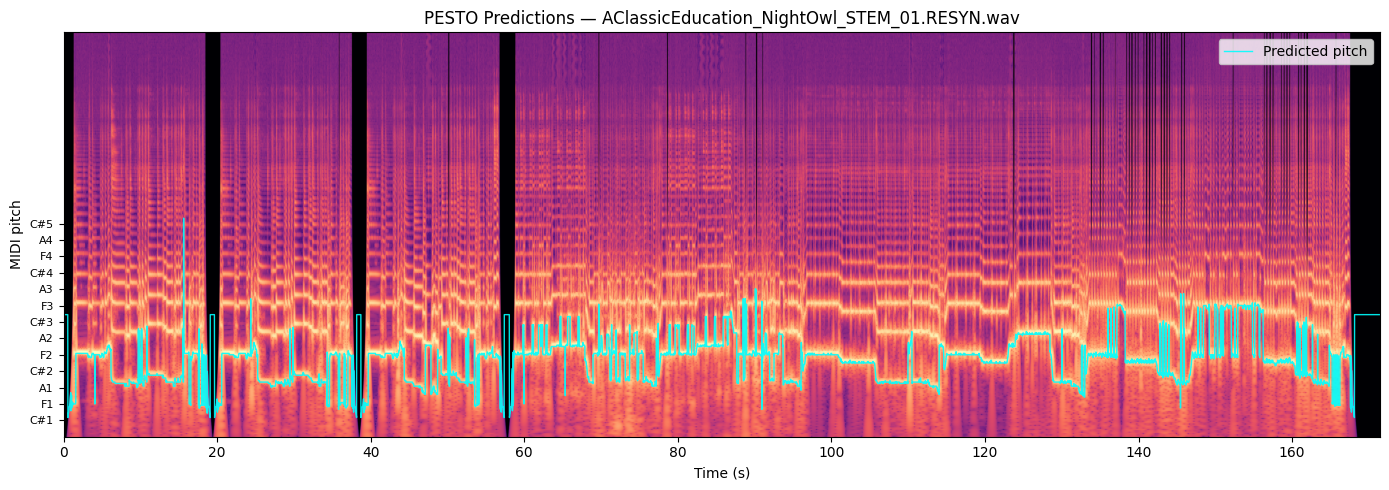

In [ ]:
# Inference & Visualisation

audio_path = "data/mdb_stem_synth/audio_stems/AClassicEducation_NightOwl_STEM_01.RESYN.wav"
# checkpoint_path = "pesto_model_from_notebook.ckpt"

# lets load the checpoint from the pesto repo for now
checkpoint_path = "mir-1k.ckpt"


# ── 1. Load checkpoint & rebuild model ───────────────────────────────────────
ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()

# ── 2. Load audio & compute HCQT ─────────────────────────────────────────────
waveform, sr = torchaudio.load(audio_path)
audio_mono = waveform.mean(dim=0)

hop_length = int(10.0 * sr / 1000 + 0.5)   # 10 ms hop
hcqt_module = HarmonicCQT(
    harmonics=list(datamodule.hcqt_kwargs["harmonics"]),
    sr=sr,
    hop_length=hop_length,
    fmin=datamodule.hcqt_kwargs["fmin"],
    bins_per_semitone=datamodule.hcqt_kwargs["bins_per_semitone"],
    n_bins=datamodule.hcqt_kwargs["n_bins"],
    center_bins=datamodule.hcqt_kwargs["center_bins"],
)

with torch.no_grad():
    hcqt = hcqt_module(audio_mono)                      # (1, harmonics, freq_bins, time, 2)
    hcqt = hcqt.squeeze(0).permute(2, 0, 1, 3)          # (time, harmonics, freq_bins, 2)

# ── 3. Run inference frame-by-frame (batched) ─────────────────────────────────
log_mag = ToLogMagnitude()
pitcher = model.pitch_shift                              # PitchShiftCQT already in the model

all_preds, all_acts = [], []
BATCH = 256

with torch.no_grad():
    for start in range(0, len(hcqt), BATCH):
        batch = torch.view_as_complex(hcqt[start:start+BATCH].float())  # (B, harmonics, freq_bins)
        batch = log_mag(batch)                           # log magnitude
        x, _, _ = pitcher(batch)                        # crop (same as forward pass)
        acts = model.encoder(x)                         # (B, output_dim)
        preds = reduce_activations(acts, reduction="alwa") - model.shift
        all_preds.append(preds)
        all_acts.append(acts)

pitches     = torch.cat(all_preds).numpy()              # (T,) predicted MIDI pitch
activations = torch.cat(all_acts).numpy()               # (T, output_dim)
times       = np.arange(len(pitches)) * hop_length / sr # time axis in seconds

# ── 4. Log-magnitude spectrogram for display ─────────────────────────────────
hcqt_display = log_mag(torch.view_as_complex(hcqt[:len(pitches), 0].float()))
hcqt_display = hcqt_display.squeeze().numpy()           # (T, freq_bins)

# ── 5. Diagnostics ────────────────────────────────────────────────────────────
print(f"Total frames:       {len(pitches)}")
print(f"Pitch range (MIDI): {pitches.min():.1f} – {pitches.max():.1f}")
print(f"Pitch sample:       {pitches[:5]}")
print(f"Model shift:        {model.shift.item():.3f}")
print(f"CQT display shape:  {hcqt_display.shape}  (T, freq_bins)")
print(f"Time axis:          {times[0]:.2f}s – {times[-1]:.2f}s")

midi_fmin = 12 * np.log2(27.5 / 440) + 69   # ≈ 21 MIDI
bps = datamodule.hcqt_kwargs["bins_per_semitone"]
pitch_bins = (pitches - midi_fmin) * bps
valid = (pitch_bins >= 0) & (pitch_bins < hcqt_display.shape[1])
print(f"Valid frames:       {valid.sum()} / {len(valid)}")
print(f"pitch_bins range:   {pitch_bins.min():.1f} – {pitch_bins.max():.1f}  (CQT has {hcqt_display.shape[1]} bins)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(hcqt_display.T, aspect="auto", origin="lower", cmap="magma",
          extent=[times[0], times[-1], 0, hcqt_display.shape[1]])
ax.plot(times, pitch_bins, c="cyan", linewidth=1, alpha=0.9, label="Predicted pitch")
ax.set_xlabel("Time (s)")
ax.set_ylabel("MIDI pitch")
ax.set_title(f"PESTO Predictions — {audio_path.split('/')[-1]}")

# Note-name y-axis ticks
notes = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
midi_ticks = np.arange(int(pitches[valid].min()), int(pitches[valid].max()) + 1, 4)
ax.set_yticks((midi_ticks - midi_fmin) * bps)
ax.set_yticklabels([f"{notes[int(m)%12]}{int(m)//12-1}" for m in midi_ticks], fontsize=8)
ax.legend(loc="upper right", markerscale=6)

plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualise Embeddings

Embeddings shape: (17145, 384)
Running UMAP on 5000 points...


/home/am/Documents/upf_smc/mir_materials_internship/icassp_tutorial/Equivariant-SSL-Tutorial/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


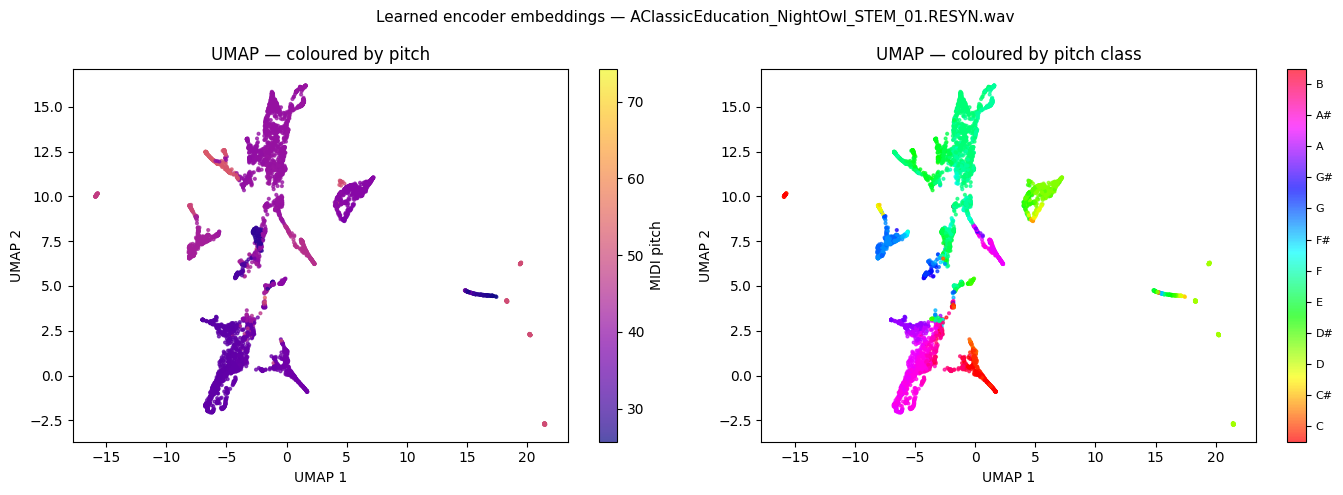

In [26]:
# Embedding Visualisation
# Extracts pre-softmax embeddings from the encoder's penultimate layer,
# reduces to 2D with UMAP (falls back to t-SNE if umap not installed),
# and colours points by predicted MIDI pitch.

# ── 1. Extract embeddings (pre-softmax, post-flatten) ────────────────────────
embeddings_list = []

def hook_fn(module, input, output):
    embeddings_list.append(input[0].detach().cpu())  # input to final_norm = pre-softmax logits

hook = model.encoder.final_norm.register_forward_hook(hook_fn)

with torch.no_grad():
    for start in range(0, len(hcqt), BATCH):
        batch = torch.view_as_complex(hcqt[start:start+BATCH].float())
        batch = log_mag(batch)
        x, _, _ = pitcher(batch)
        model.encoder(x)

hook.remove()

embeddings = torch.cat(embeddings_list).numpy()   # (T, output_dim)
print(f"Embeddings shape: {embeddings.shape}")

# ── 2. Dimensionality reduction ───────────────────────────────────────────────
# Subsample for speed if the audio is long
MAX_POINTS = 5000
if len(embeddings) > MAX_POINTS:
    idx = np.random.choice(len(embeddings), MAX_POINTS, replace=False)
    idx.sort()
    emb_sample   = embeddings[idx]
    pitch_sample = pitches[idx]
else:
    emb_sample   = embeddings
    pitch_sample = pitches

try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    method_name = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    method_name = "t-SNE"

print(f"Running {method_name} on {len(emb_sample)} points...")
emb_2d = reducer.fit_transform(emb_sample)
print("Done.")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: coloured by MIDI pitch
sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=pitch_sample, cmap="plasma", s=4, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="MIDI pitch")
axes[0].set_title(f"{method_name} — coloured by pitch")
axes[0].set_xlabel(f"{method_name} 1")
axes[0].set_ylabel(f"{method_name} 2")

# Panel 2: coloured by pitch class (chroma) — reveals octave structure
notes = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
pitch_class = pitch_sample % 12
sc2 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1],
                      c=pitch_class, cmap="hsv", vmin=0, vmax=12, s=4, alpha=0.7)
cbar = plt.colorbar(sc2, ax=axes[1], ticks=np.arange(0.5, 12))
cbar.ax.set_yticklabels(notes, fontsize=8)
axes[1].set_title(f"{method_name} — coloured by pitch class")
axes[1].set_xlabel(f"{method_name} 1")
axes[1].set_ylabel(f"{method_name} 2")

plt.suptitle(f"Learned encoder embeddings — {audio_path.split('/')[-1]}", fontsize=11)
plt.tight_layout()
plt.savefig("embeddings.png", dpi=150, bbox_inches="tight")
plt.show()